In [19]:
import stable_baselines3
from raiSimulationEnvATKDEF import RobotSimEnv
import robotic as ry
import numpy as np
import time

import os
import numpy as np
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
from stable_baselines3 import PPO
import gymnasium as gym

class RewardLoggerCallback(BaseCallback):
    def __init__(self, log_file: str, verbose: int = 0):
        super(RewardLoggerCallback, self).__init__(verbose)
        self.log_file = log_file
        self.episode_rewards = []
        self.current_episode_reward = 0

        # Create the log file if it doesn't exist
        if not os.path.exists(self.log_file):
            with open(self.log_file, 'w') as f:
                f.write("Episode,Total Reward\n")

    def _on_step(self) -> bool:
        # Check if the episode has ended by using `done`
        dones = self.locals["dones"]
        rewards = self.locals["rewards"]

        # Accumulate rewards for the current episode
        self.current_episode_reward += rewards[0]

        # If the episode is done, log the reward
        if dones[0]:
            self.episode_rewards.append(self.current_episode_reward)
            with open(self.log_file, 'a') as f:
                f.write(f"{len(self.episode_rewards)},{self.current_episode_reward}\n")
            # Reset the reward counter for the next episode
            self.current_episode_reward = 0


        return True

    def _on_training_end(self) -> None:
        # Optionally summarize results at the end of training
        print("Training finished. Total episodes:", len(self.episode_rewards))
        print("Episode rewards:", self.episode_rewards)

class CustomCheckpointCallback(BaseCallback):
    def __init__(self, save_freq, save_path, verbose=0):
        super(CustomCheckpointCallback, self).__init__(verbose)
        self.save_freq = save_freq
        self.save_path = save_path

    def _on_step(self) -> bool:
        # Save the model every `save_freq` steps
        if self.n_calls % self.save_freq == 0:
            model_path = f"{self.save_path}/model_checkpoint_{self.n_calls}_steps.zip"
            self.model.save(model_path)
            if self.verbose > 0:
                print(f"Model saved at step {self.n_calls} to {model_path}")
        return True

class StaticOpponentWrapper(gym.Wrapper):
    """
    A wrapper for a 1v1 environment where one agent is controlled by a fixed, pre-trained policy.
    """
    def __init__(self, env, static_policy_attacker, static_policy_defender,attacker=True,test=False):
        super(StaticOpponentWrapper, self).__init__(env)
        self.static_policy_attacker = static_policy_attacker
        self.static_policy_defender = static_policy_defender
        self.attacker = attacker
        self.test = test

    def step(self, action):
        # Get the static opponent's action
        obs = self.env.state  # Modify this based on how your env works
        attacker_action, _ = self.static_policy_attacker.predict(obs, deterministic=True)
        defender_action, _ = self.static_policy_defender.predict(obs, deterministic=True)
        # Combine both actions into a joint action
        if self.attacker:
            joint_action = (attacker_action, action)
        else:
            joint_action = (action,defender_action)
        
        if self.test:
            joint_action = (attacker_action, defender_action)

        # Step the environment with both actions
        obs, reward, done, truncated, info = self.env.step(joint_action)
        return obs, reward, done, truncated, info

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)

from collections import OrderedDict

def update_ordered_dict_keys(ordered_dict, key_mapping):
    """
    Update keys in an OrderedDict based on a key mapping dictionary.

    Args:
        ordered_dict (OrderedDict): The OrderedDict to update.
        key_mapping (dict): A dictionary where keys are the old keys to be replaced,
                            and values are the new keys.

    Returns:
        OrderedDict: A new OrderedDict with updated keys.
    """
    updated_dict = OrderedDict()

    for old_key, value in ordered_dict.items():
        # Use the new key if it exists in the key_mapping, otherwise keep the old key
        new_key = key_mapping.get(old_key, old_key)
        updated_dict[new_key] = value

    return updated_dict

def delete_values_from_ordered_dict(ordered_dict, keys_to_delete):
    """
    Create a new OrderedDict with specific keys removed.

    Args:
        ordered_dict (OrderedDict): The original OrderedDict.
        keys_to_delete (list): A list of keys to be removed.

    Returns:
        OrderedDict: A new OrderedDict with specified keys removed.
    """
    return OrderedDict((key, value) for key, value in ordered_dict.items() if key not in keys_to_delete)


def select_keys(ordered_dict, keys):
    """
    Select specific keys from an OrderedDict and return a new OrderedDict with only the selected keys.

    Parameters:
        ordered_dict (OrderedDict): The original OrderedDict.
        keys (list): List of keys to select from the OrderedDict.

    Returns:
        OrderedDict: A new OrderedDict containing only the selected keys.
    """
    return OrderedDict((key, ordered_dict[key]) for key in keys if key in ordered_dict)


In [ ]:

env = RobotSimEnv(render_mode='human')

policy_kwargs = dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))


model = PPO("MlpPolicy", env, policy_kwargs=policy_kwargs, verbose=0)

reward_logger = RewardLoggerCallback(log_file="rewards_log_baranpath.csv")
model.learn(total_timesteps=100000,progress_bar=True,callback=reward_logger)

In [20]:
from stable_baselines3 import PPO
import time
import torch

env = RobotSimEnv(render_mode='human',staticAttacker=True, staticDefender=True)
policy_kwargs = dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))

# attackModel = PPO.load("ppo_200k_attack_trial5")
# defenceModel = PPO.load("model_checkpoint_200000_steps")
attackModel = PPO.load("sword_best")
defenceModel = PPO.load("shield_best")
# attackModel = PPO.load("Iterative_attack_trial_14")
# defenceModel = PPO.load("Iterative_defence_trial_15")

# defenceModel = PPO("MlpPolicy", env, policy_kwargs=policy_kwargs, verbose=0)

# model2 = torch.load("defence_model_imitation_posdif.pth")
# defenceModel.policy.mlp_extractor.load_state_dict(delete_values_from_ordered_dict(model2,["action_net.weight","action_net.bias","value_out.weight","value_out.bias"]))
# defenceModel.policy.value_net.load_state_dict(update_ordered_dict_keys(select_keys(model2,["value_out.weight","value_out.bias"]),{"value_out.weight":"weight","value_out.bias":"bias"}))
# defenceModel.policy.action_net.load_state_dict(update_ordered_dict_keys(select_keys(model2,["action_net.weight","action_net.bias"]),{"action_net.weight":"weight","action_net.bias":"bias"}))

wrapped_env = StaticOpponentWrapper(env, attackModel,defenceModel,attacker=True,test=True)

policy_kwargs = dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))


model = PPO("MlpPolicy", wrapped_env, policy_kwargs=policy_kwargs, verbose=0, device='cpu')   

vec_env = model.get_env()
obs = vec_env.reset()
#env.render()
time.sleep(1)
# specify random seed
# torch.manual_seed(4\7)
# np.random.seed(47)
attackSuccessesRates = []
defenceSuccessesRates = []
for i in range(1000):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = vec_env.step(action)
    if done:
        #attackSuccessesRates.append(env.attackSuccess/(env.attackSuccess+env.defenceSuccess))
        #defenceSuccessesRates.append(env.defenceSuccess/(env.attackSuccess+env.defenceSuccess))
        print("attack success rate", env.attackSuccess/(env.attackSuccess+env.defenceSuccess))
        print("defence success rate", env.defenceSuccess/(env.attackSuccess+env.defenceSuccess))
    env.render()
    # VecEnv resets automatically
    # if done:
    #   obs = env.reset()



-- kin_physx.cpp:addJoint:298(0) ADDING JOINT l_panda_joint7-sword_0 of type rigid with rel [0, 0, 0]
-- kin_physx.cpp:addJoint:298(0) ADDING JOINT r_panda_joint7-shi of type rigid with rel [0, 0, 0]
-- kin_physx.cpp:addJoint:298(0) ADDING JOINT l_panda_joint7-sword_0 of type rigid with rel [0, 0, 0]
-- kin_physx.cpp:addJoint:298(0) ADDING JOINT r_panda_joint7-shi of type rigid with rel [0, 0, 0]
attack success rate 0.0
defence success rate 1.0
-- kin_physx.cpp:addJoint:298(0) ADDING JOINT l_panda_joint7-sword_0 of type rigid with rel [0, 0, 0]
-- kin_physx.cpp:addJoint:298(0) ADDING JOINT r_panda_joint7-shi of type rigid with rel [0, 0, 0]
attack success rate 0.5
defence success rate 0.5
-- kin_physx.cpp:addJoint:298(0) ADDING JOINT l_panda_joint7-sword_0 of type rigid with rel [0, 0, 0]
-- kin_physx.cpp:addJoint:298(0) ADDING JOINT r_panda_joint7-shi of type rigid with rel [0, 0, 0]
attack success rate 0.6666666666666666
defence success rate 0.3333333333333333
-- kin_physx.cpp:addJoi

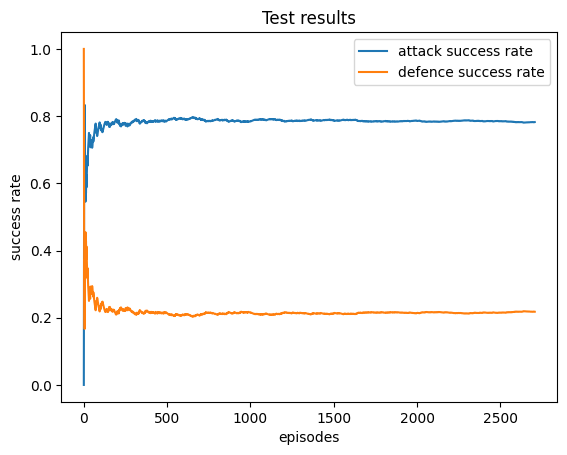

In [13]:
import matplotlib.pyplot as plt

plt.plot(np.array([np.array(attackSuccessesRates),np.array(defenceSuccessesRates)]).T)
plt.legend(["attack success rate","defence success rate"])
plt.xlabel("episodes")
plt.ylabel("success rate")
plt.title("Test results")
plt.savefig("test_results.png")